# Notebook for testing aspects of the Diffusers library
Current list of sections:
1. VAE

## VAE

/media/aris/Data/master2025dev/aris_master/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


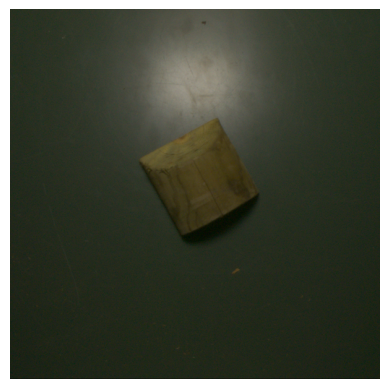

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027126431..0.62123775].


Latents shape: torch.Size([1, 4, 64, 64])
Reconstructed image shape: torch.Size([1, 3, 512, 512])


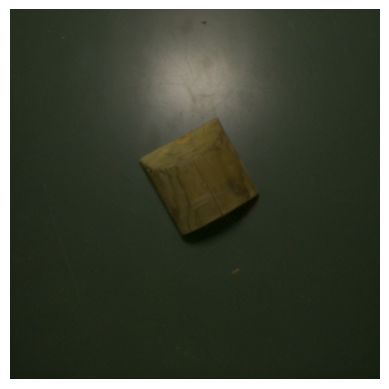

In [1]:
# Change working directory to parent directory
import os
os.chdir("/media/aris/Data/master2025dev/aris_master")
device = "cuda"
from diffusers import AutoencoderKL

# ----------- Download model from Hugging Face and save it locally ----------- #
"""
# url = "https://huggingface.co/stabilityai/sd-vae-ft-mse-original/blob/main/vae-ft-mse-840000-ema-pruned.safetensors"  # can also be a local file
# model = AutoencoderKL.from_single_file(url)
# Save the model to current working directory
# save_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
# model.save_pretrained(save_path)

# Print files in the specified directory
# vae_directory = os.path.join(os.getcwd(), "models/VAE/")
# print("Files in VAE directory:", os.listdir(vae_directory))
"""

# # --------------------------- import model locally --------------------------- #
local_model_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
vae = AutoencoderKL.from_pretrained(local_model_path)
vae.to(device)

# # Test the model by printing its configuration
# print("Model configuration:", model.config)

# Test the model with image
img_path = "/media/aris/Data/master2025dev/datasets/wood/v2_512x512/train/impregnated_wood/images/img_bold-eagle_2024-11-04T16-33-09-968.png"
from PIL import Image
image = Image.open(img_path).convert("RGB")

#convert image to tensor
from torchvision import transforms
transform = transforms.Compose([
    # transforms.Resize((600, 960)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
image = transform(image).unsqueeze(0).to(device)

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_input.png"
#Limit image to valid range and convert to PIL
img = (image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
img = transforms.ToPILImage()(img)
img.save(save_path)


# plot image 
import matplotlib.pyplot as plt
plt.imshow((image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()
# latents = model.encode(image)


# ---------------------------------- encode ---------------------------------- #
import torch    
with torch.no_grad():
    latents = vae.encode(image).latent_dist.sample()
print("Latents shape:", latents.shape)

# ---------------------------------- decode ---------------------------------- #
with torch.no_grad():
    reconstructed_image = vae.decode(latents).sample
    
print("Reconstructed image shape:", reconstructed_image.shape)
# plot reconstructed image
plt.imshow((reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_output.png"
#Limit image to valid range and convert to PIL
img = (reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
reconstructed_image_pil = transforms.ToPILImage()(img)
reconstructed_image_pil.save(save_path)






#vae.to("cpu")




## Unet2DConditionModel
Following code attempts to create a Unet2DConditionModel and apply it

In [2]:
from diffusers import UNet2DConditionModel
local_model_path = os.path.join(os.getcwd(), "models/UNet/runwayml-stable-diffusion-v1-5")
unet = UNet2DConditionModel.from_pretrained(local_model_path)

unet.to(device)
print("UNet model loaded successfully.")
#print model config
print("Model configuration:", unet.config)


#Map image to latents
latents = vae.encode(image)

print("Latents shape:", latents.latent_dist.sample().shape)

output_latents = unet(latents.latent_dist.sample(), timestep=10, encoder_hidden_states=torch.randn(1, 77, 768).to(device))
print("Output latents shape:", output_latents.sample.shape)

UNet model loaded successfully.
Model configuration: FrozenDict([('sample_size', 64), ('in_channels', 4), ('out_channels', 4), ('center_input_sample', False), ('flip_sin_to_cos', True), ('freq_shift', 0), ('down_block_types', ['CrossAttnDownBlock2D', 'CrossAttnDownBlock2D', 'CrossAttnDownBlock2D', 'DownBlock2D']), ('mid_block_type', 'UNetMidBlock2DCrossAttn'), ('up_block_types', ['UpBlock2D', 'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D']), ('only_cross_attention', False), ('block_out_channels', [320, 640, 1280, 1280]), ('layers_per_block', 2), ('downsample_padding', 1), ('mid_block_scale_factor', 1), ('dropout', 0.0), ('act_fn', 'silu'), ('norm_num_groups', 32), ('norm_eps', 1e-05), ('cross_attention_dim', 768), ('transformer_layers_per_block', 1), ('reverse_transformer_layers_per_block', None), ('encoder_hid_dim', None), ('encoder_hid_dim_type', None), ('attention_head_dim', 8), ('num_attention_heads', None), ('dual_cross_attention', False), ('use_linear_projection